In [ ]:
%pip install pandas matplotlib seaborn rdkit torch torch_geometric optuna tqdm

In [16]:
import os
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from collections import Counter
import numpy as np

# Rutas (Ajusta esto a tu carpeta)
BASE_DIR = '../data'  # Donde tengas tus archivos descomprimidos
LIGAND_DIR = os.path.join(BASE_DIR, 'Ligand')
PROTEIN_DIR = os.path.join(BASE_DIR, 'Protein')
INTERACTION_DIR = os.path.join(BASE_DIR, 'Interaction')

# Función para limpiar tus listas de listas [['ID'], ['ID']]
def load_clean_ids(filename):
    path = os.path.join(BASE_DIR, filename)
    with open(path, 'r') as f:
        # ast.literal_eval convierte el string "['A', 'B']" en una lista real
        raw_list = ast.literal_eval(f.read())
        # Aplanamos la lista (flatten)
        flat_list = [item for sublist in raw_list for item in sublist]
    return flat_list

# Cargar los IDs
train_ids = load_clean_ids('Splits/train_index_folder.txt')
valid_ids = load_clean_ids('Splits/valid_index_folder.txt')
test_ids = load_clean_ids('Splits/test_index_folder.txt')

print(f"Total Train: {len(train_ids)}")
print(f"Total Valid: {len(valid_ids)}")
print(f"Total Test: {len(test_ids)}")
print(f"Ejemplo de ID: {train_ids[0]}")

Total Train: 1056
Total Valid: 260
Total Test: 329
Ejemplo de ID: 7GIO


IDs de Train sin pIC50: 0
            pIC50
count  378.000000
mean     5.952222
std      0.977909
min      4.004233
25%      5.289404
50%      6.021413
75%      6.675301
max      8.568636


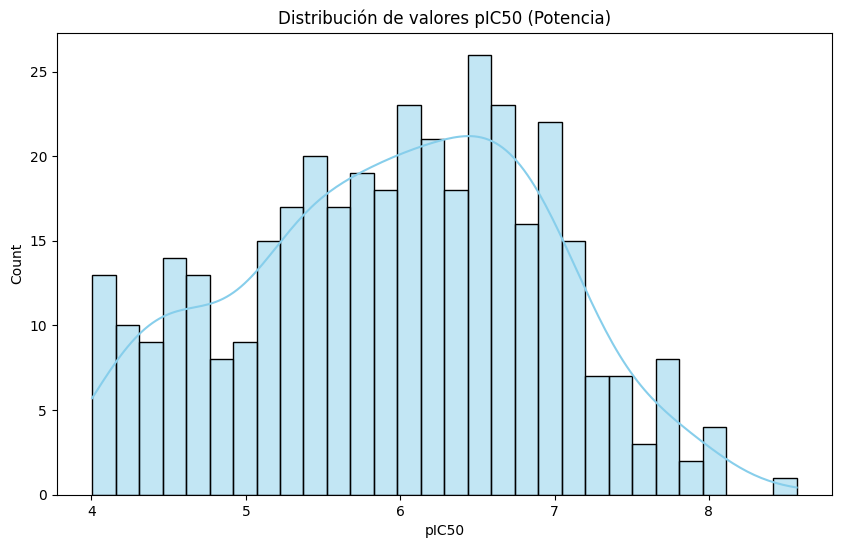

In [5]:
targets = {}
with open(os.path.join(BASE_DIR, 'pIC50.txt'), 'r') as f:
    for line in f:
        parts = line.split()
        if len(parts) >= 2:
            targets[parts[0]] = float(parts[1])

# Convertir a DataFrame para facilitar el análisis
df_targets = pd.DataFrame(list(targets.items()), columns=['PDB_ID', 'pIC50'])

# Comprobación de integridad
missing_train = [uid for uid in train_ids if uid not in targets]
print(f"IDs de Train sin pIC50: {len(missing_train)}")
if missing_train:
    print(f"Faltan: {missing_train}")

# Estadísticas básicas
print(df_targets.describe())

# Histograma para ver si los datos están balanceados
plt.figure(figsize=(10, 6))
sns.histplot(df_targets['pIC50'], kde=True, bins=30, color='skyblue')
plt.title('Distribución de valores pIC50 (Potencia)')
plt.xlabel('pIC50')
plt.show()

Mostrando 8 moléculas:


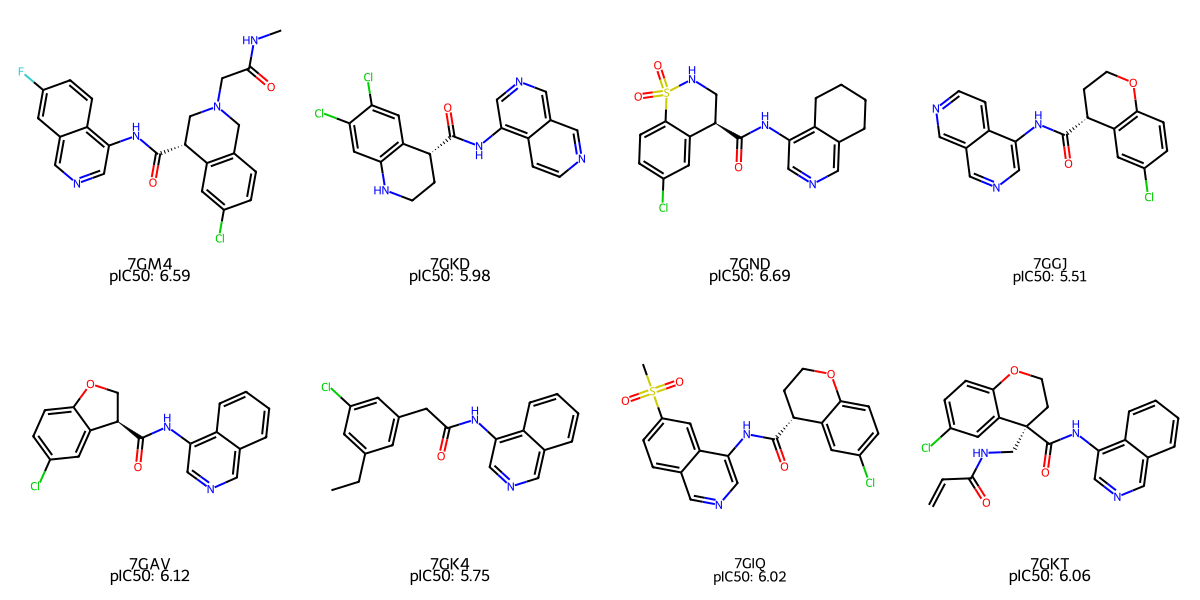

In [6]:
def visualizar_ligandos_2D(ids_list, num_samples=8):
    mols = []
    legends = []
    valid_count = 0
    
    # Iteramos sobre el doble de los necesarios por si algún archivo falla
    for pdb_id in ids_list[:num_samples*2]:
        sdf_path = os.path.join(LIGAND_DIR, f"{pdb_id}_ligand.sdf") 
        
        if not os.path.exists(sdf_path):
            continue
            
        # Leemos el archivo (sanitize=True arregla pequeños errores químicos)
        supplier = Chem.SDMolSupplier(sdf_path, sanitize=True)
        mol = supplier[0] if len(supplier) > 0 else None
        
        if mol:
            AllChem.Compute2DCoords(mol) 
            mols.append(mol)
            
            # Buscamos el valor pIC50 para ponerlo de etiqueta
            val = targets.get(pdb_id, "N/A")
            val_str = f"{val:.2f}" if isinstance(val, float) else val
            legends.append(f"{pdb_id}\npIC50: {val_str}")
            
            valid_count += 1
            if valid_count >= num_samples:
                break
        else:
            print(f"Error leyendo estructura química de: {pdb_id}")

    # Dibujamos el grid
    print(f"Mostrando {len(mols)} moléculas:")
    img = Draw.MolsToGridImage(
        mols, 
        molsPerRow=4, 
        subImgSize=(300, 300), 
        legends=legends
    )
    return img

visualizar_ligandos_2D(valid_ids)

In [7]:
bad_files = []
for filename in os.listdir(LIGAND_DIR):
    if filename.endswith(".sdf"):
        path = os.path.join(LIGAND_DIR, filename)
        if os.path.getsize(path) == 0:
            bad_files.append(filename)

print(f"Archivos vacíos (0 bytes): {len(bad_files)}")
print(bad_files)

Archivos vacíos (0 bytes): 0
[]


In [13]:
missing_proteins = []
missing_jsons = []

for pdb_id in targets.keys(): # targets es tu diccionario de pIC50
    pdb_path = os.path.join(PROTEIN_DIR, f"{pdb_id}_protein.pdb")
    json_path = os.path.join(INTERACTION_DIR, f"{pdb_id}_ligand.json")
        
    # Comprobamos la proteína
    if not os.path.exists(pdb_path) or os.path.getsize(pdb_path) == 0:
        missing_proteins.append(pdb_id)
        
    # Comprobamos el JSON
    if not os.path.exists(json_path) or os.path.getsize(json_path) == 0:
        missing_jsons.append(pdb_id)

print(f"Proteínas faltantes o vacías: {len(missing_proteins)}")
if len(missing_proteins) > 0: print(missing_proteins[:5])

print(f"JSONs de interacción faltantes o vacíos: {len(missing_jsons)}")
if len(missing_jsons) > 0: print(missing_jsons[:5])
print("-------------------------------------------------")

Proteínas faltantes o vacías: 0
JSONs de interacción faltantes o vacíos: 0
-------------------------------------------------


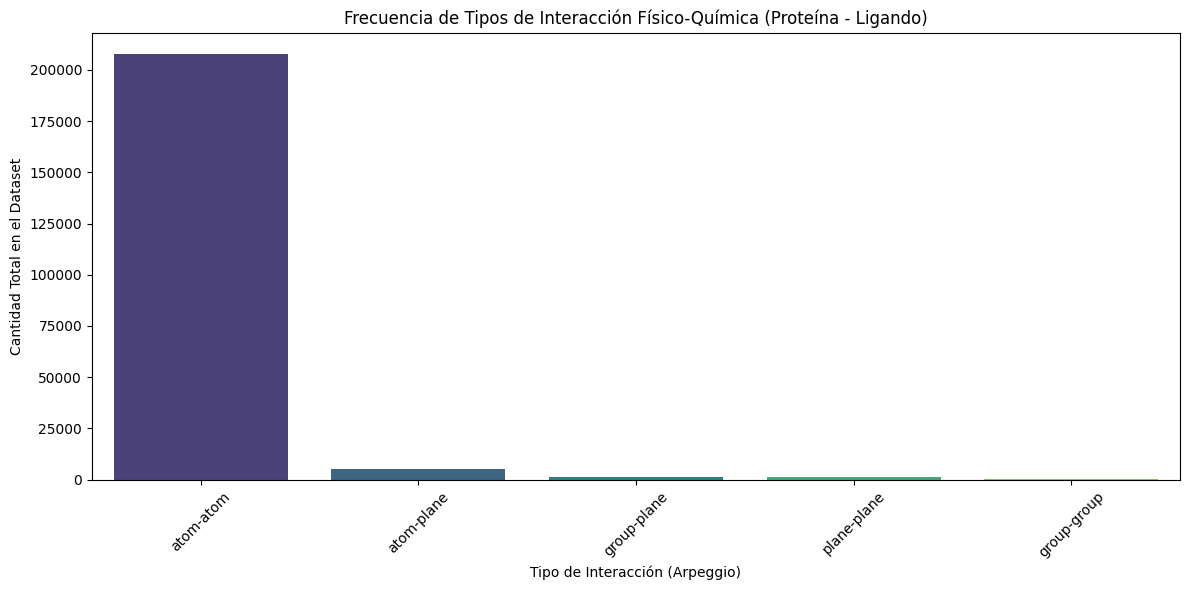

Media de interacciones por fármaco: 570.1
Máximo de interacciones en un solo fármaco: 984


In [18]:

interaction_counts = Counter()
total_interactions_per_ligand = []

# Recorremos todos los JSONs válidos
for pdb_id in targets.keys():
    json_path = os.path.join(INTERACTION_DIR, f"{pdb_id}_ligand.json")
    
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            try:
                interactions = json.load(f)
                count_for_this_ligand = 0
                
                for inter in interactions:
                    if inter.get('interacting_entities') == 'INTER':
                        # Contamos el tipo de interacción (hbond, hydrophobic, etc.)
                        interaction_counts[inter['type']] += 1
                        count_for_this_ligand += 1
                        
                total_interactions_per_ligand.append(count_for_this_ligand)
            except:
                pass # Si algún JSON está corrupto, lo saltamos

# 1. Gráfico de tipos de interacciones
plt.figure(figsize=(12, 6))
inter_df = pd.DataFrame.from_dict(interaction_counts, orient='index', columns=['Frecuencia']).sort_values('Frecuencia', ascending=False)
sns.barplot(x=inter_df.index, y=inter_df['Frecuencia'], hue=inter_df.index, palette='viridis', legend=False)
plt.title('Frecuencia de Tipos de Interacción Físico-Química (Proteína - Ligando)')
plt.ylabel('Cantidad Total en el Dataset')
plt.xlabel('Tipo de Interacción (Arpeggio)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Imprimir estadísticas básicas
print(f"Media de interacciones por fármaco: {np.mean(total_interactions_per_ligand):.1f}")
print(f"Máximo de interacciones en un solo fármaco: {np.max(total_interactions_per_ligand)}")